In [11]:
import jax
import jax.numpy as jnp
import seaborn as sns
import matplotlib.pyplot as plt
import equinox as eqx
import equinox.nn as nn
import snnax.snn as snn
import optax

from jax.lax import stop_gradient, clamp
from snnax.snn.layers.stateful import StatefulLayer, StateShape, default_init_fn, StatefulOutput
from snnax.functional.surrogate import superspike_surrogate, SpikeFn
from typing import Union, Literal, Callable, Optional, Sequence
from tqdm import trange
from spyx.axn import arctan
from jaxtyping import Array, PRNGKeyArray
from spyx.loaders import SHD_loader
from eleanor.models import Heracles, Scaler, FeLIF, FeLIFV2
from eleanor.weight_quantization import quantize_weights, QuantizedLinear
from chex import Array, PRNGKey



In [12]:
# from typing import Union, Literal, Callable, Optional, Sequence

# import jax
# import optax
# import equinox as eqx
# import seaborn as sns
# import jax.numpy as jnp
# import matplotlib.pyplot as plt
# from tqdm import trange
# from spyx.axn import arctan
# from jaxtyping import Array, PRNGKeyArray
# from spyx.loaders import SHD_loader


In [13]:
# @title Parameters
batch_size = 128  # @param {type:"number"}
nb_epochs = 200  # @param {type:"number"}
nb_steps = 72  # @param {type:"number"}
nb_inputs = 700  # @param {type:"number"}
nb_hidden = 200  # @param {type:"number"}
nb_outputs = 20  # @param {type:"number"}
save_every = 10  # @param {type:"number"}
learning_rate = 2e-4  # @param {type:"number"}
time_step = 14e-3  # @param {type:"number"}

tau_mem = 1680e-3  # @param {type:"number"}
tau_syn = 5e-3  # @param {type:"number"}

alpha = jnp.exp(-time_step / tau_syn)
beta = jnp.exp(-time_step / tau_mem)

_spike_fn = arctan(k=2)

In [14]:
# Updated RCUBALIF version

class rcubaLIF(StatefulLayer):
    """
    TODO improve docstring
    Implementation of a leaky integrate-and-fire neuron with
    synaptic currents. Requires two decay constants to describe
    decay of membrane potential and synaptic current.

    Arguments:

        `decay_constants` (Array): Decay constants for the LIF neuron.
        `spike_fn` (SpikeFn): Spike treshold function with custom surrogate gradient.
        `threshold` (Array): Spike threshold for membrane potential. Defaults to 1.
        `reset_val` (Array): Reset value after a spike has been emitted. 
                        Defaults to None.
        `stop_reset_grad` (bool): Boolean to control if the gradient is propagated
                            through the refectory potential.
        `init_fn` (Callable): Function to initialize the state of the spiking neurons.
                    Defaults to initialization with zeros if 
                    nothing else is provided.
        `shape` (Sequence[int]): Shape of the neuron layer.
        `key` (PRNGKey): Random number generator key for initialization of parameters.
    """
    decay_constants: Array
    threshold: Array
    spike_fn: SpikeFn
    reset_val: Array
    recurrent: eqx.nn.Linear
    stop_reset_grad: bool

    def __init__(self, 
                hidden_size: int,
                decay_constants: Union[Sequence[float], Array],
                spike_fn: SpikeFn = superspike_surrogate(10.),
                threshold: Array = 1.,
                stop_reset_grad: bool = True,
                reset_val: Optional[Array] = None,
                init_fn: Optional[Callable] = default_init_fn,
                shape: Optional[StateShape] = None,
                key: Optional[PRNGKey] = None) -> None:

        super().__init__(init_fn, shape)
        self.threshold = threshold
        self.spike_fn = spike_fn
        self.reset_val = reset_val
        self.stop_reset_grad = stop_reset_grad
        self.decay_constants = self.init_parameters(decay_constants, shape)
        self.recurrent = QuantizedLinear(hidden_size, hidden_size, key=key, quant_bits=8)

    def init_state(self, 
                    shape: StateShape, 
                    key: PRNGKey, 
                    *args, 
                    **kwargs) -> Sequence[Array]:
        init_state_mem_pot = self.init_fn(shape, key, *args, **kwargs)
        
        # The synaptic currents are initialized as zeros
        init_state_syn_curr = jnp.zeros(shape) 
        
        # The spiking outputs are initialized as zeros
        init_state_spike_output = jnp.zeros(shape)
        return [init_state_mem_pot, init_state_syn_curr, init_state_spike_output]

    def __call__(self, 
                state: Sequence[Array], 
                synaptic_input: Array,
                *, key: Optional[PRNGKey] = None) -> StatefulOutput:
        mem_pot, syn_curr, spike_output = state
        
        if self.reset_val is None:
            reset_pot = mem_pot*spike_output 
        else:
            reset_pot = (mem_pot-self.reset_val)*spike_output 

        # Optionally stop gradient propagation through refectory potential       
        refectory_potential = stop_gradient(reset_pot) if self.stop_reset_grad else reset_pot
        mem_pot = mem_pot - refectory_potential

        alpha = clamp(0.5, self.decay_constants[0], 1.0)
        beta  = clamp(0.5, self.decay_constants[1], 1.0)
        
        mem_pot = alpha*mem_pot + (1.-alpha)*syn_curr
        syn_curr = beta*syn_curr + synaptic_input + self.recurrent(spike_output, key=key) #Added recurrency here
        

        spike_output = self.spike_fn(mem_pot - self.threshold)

        state = [mem_pot, syn_curr, spike_output]
        return [state, spike_output]


In [15]:
# Old RCUBALIF version

# class RCUBALIF(eqx.Module):
#     hidden_size: int = eqx.field(static=True)
#     alpha: float = eqx.field(static=True)
#     beta: float = eqx.field(static=True)
#     recurrent: eqx.nn.Linear

#     def __init__(self, hidden_size, alpha, beta, *, key=None):
#         self.hidden_size = hidden_size
#         self.alpha = alpha
#         self.beta = beta
#         self.recurrent = eqx.nn.Linear(hidden_size, hidden_size, key=key)

#     def __call__(self, input_, key=key):
#         hidden = (jnp.zeros((self.hidden_size,)), jnp.zeros((self.hidden_size,)))

#         def f(carry, inp):
#             syn, mem = carry

#             mtr = mem - 1.0
#             out = _spike_fn(mtr)
#             rst = jax.lax.stop_gradient(out)

#             new_syn = self.alpha * syn + inp + self.recurrent(out)
#             new_mem = (self.beta * mem) * (1.0 - rst) + new_syn

#             return (new_syn, new_mem), out

#         _, out = jax.lax.scan(f, hidden, input_)
#         # out = out[-1]  # !!! Added as kept getting incompatible shapes, couldn't fix elsewhere


#         return out


In [16]:
key = jax.random.key(0)
key1, key2, key3, key4, key5, key6 = jax.random.split(key, 6)


class EncodingLayer(eqx.Module):

    gain: Array
    bias: Array
    expansion: float

    def __init__(self, gain: Array, bias: Array, expansion: float) -> None:
        self.gain = gain
        self.bias = bias
        self.expansion = expansion

    def __call__(self, synaptic_input: Array, *, key: Optional[PRNGKey] = None):
        output = self.gain * (jnp.tile(synaptic_input, self.expansion) + self.bias)
        return output


# enc_gain = jax.random.normal(key1, shape=(700,)) * 0.18436009935019085
# enc_bias = jax.random.normal(key2, shape=(700,))
model = snn.Sequential(
    # EncodingLayer(enc_gain, enc_bias, 32),
    QuantizedLinear(700, 200, key=key3, quant_bits=8),
    # snn.LIF([0.9, 0.8], key=key4),
    rcubaLIF(200, [alpha, beta], key=key4),
    QuantizedLinear(200, 20, key=key5, quant_bits=8),
    snn.LIF([.9, .8], key=key6),
    # Scaler(100, 100),
    # FeLIFV2(dt=1e-3, V_thr=0.3, paramsScale=1e12),
)
model

Sequential(
  graph_structure=GraphStructure(
    num_layers=4,
    input_layer_ids=((0,), (), (), ()),
    input_connectivity=((), (0,), (1,), (2,))
  ),
  layers=[
    QuantizedLinear(
      weight=f32[200,700],
      bias=f32[200],
      in_features=700,
      out_features=200,
      use_bias=True,
      quant_bits=8
    ),
    rcubaLIF(
      init_fn=<function <lambda>>,
      shape=None,
      decay_constants=f32[2],
      threshold=1.0,
      spike_fn=<function heaviside_with_superspike_surrogate>,
      reset_val=None,
      recurrent=QuantizedLinear(
        weight=f32[200,200],
        bias=f32[200],
        in_features=200,
        out_features=200,
        use_bias=True,
        quant_bits=8
      ),
      stop_reset_grad=True
    ),
    QuantizedLinear(
      weight=f32[20,200],
      bias=f32[20],
      in_features=200,
      out_features=20,
      use_bias=True,
      quant_bits=8
    ),
    LIF(
      init_fn=<function <lambda>>,
      shape=None,
      decay_constants=f

In [17]:
from functools import partial
from jax.tree_util import tree_map


# Simple batched loss function
@partial(jax.vmap, in_axes=(None, None, 0, 0, 0))
def loss_fn(model, in_states, in_spikes, tgt_class, key):
    out_state, out_spikes = model(in_states, in_spikes, key=key)

    # Get the output of last layer
    # final_layer_out = out_spikes[-1][0]
    final_layer_out = out_spikes[-1]
    # final_layer_out = out_spikes

    # Sum all spikes in each output neuron along time axis
    # pred = tree_map(lambda x: jnp.sum(x, axis=0), final_layer_out)
    pred = final_layer_out.sum(axis=0)

    target = jax.nn.one_hot(tgt_class, 20)
    loss = optax.softmax_cross_entropy(pred, target)
    return loss


# Calculating the gradient with Equinox PyTree filters and
# subsequently jitting the resulting function
@eqx.filter_value_and_grad
def loss_and_grad(model, in_states, in_spikes, tgt_class, key):
    keys = jax.random.split(key, 128)
    return jnp.mean(loss_fn(model, in_states, in_spikes, tgt_class, keys))


@partial(jax.vmap, in_axes=(None, None, 0, 0, 0))
def accuracy_fn(model, in_states, in_spikes, tgt_class, key):
    out_state, out_spikes = model(in_states, in_spikes, key=key)
    # final_layer_out = out_spikes[-1][0]
    final_layer_out = out_spikes[-1]
    # final_layer_out = out_spikes
    pred = final_layer_out.sum(axis=0)
    predicted_class = jnp.argmax(pred)
    return predicted_class == tgt_class


@eqx.filter_jit
def calc_accuracy(model, in_states, in_spikes, tgt_class, key):
    keys = jax.random.split(key, 128)
    accuracy = accuracy_fn(model, in_states, in_spikes, tgt_class, keys)
    return jnp.mean(accuracy)


# Finally, we update the parameters using a simple optimizer
@eqx.filter_jit
def update(model, in_states, opt_state, in_spikes, tgt_class, key):
    # Get gradients
    loss, grads = loss_and_grad(model, in_states, in_spikes, tgt_class, key)

    # Calculate parameter updates using the optimizer
    updates, opt_state = optim.update(grads, opt_state)

    # Update parameter PyTree with Equinox and optax
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

In [18]:
shd_dl = SHD_loader(batch_size, nb_steps, nb_inputs, 0.2)

100%|██████████| 100/100 [00:37<00:00,  2.67it/s]


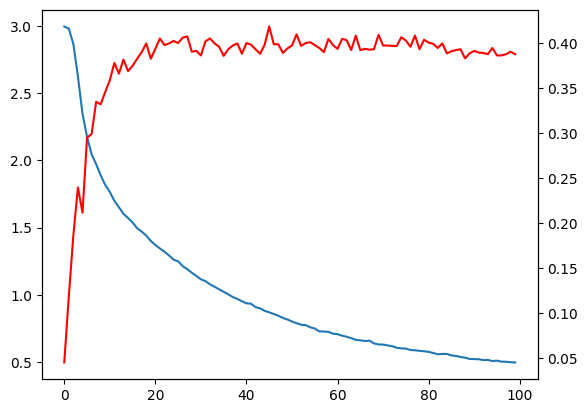

In [19]:
optim = optax.adamax(learning_rate=1e-3, b1=0.9, b2=0.995)
opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

initial_state = model.init_state(in_shape=(700,), key=jax.random.key(0)) # !!!
total_loss = []
total_accuracy = []


pbar = trange(0, 100)
for epoch in pbar:
    key, epoch_key = jax.random.split(key)
    # x_train, y_train = shuffle(trainset, epoch_key, 128)
    x_train, y_train = shd_dl.train_epoch(epoch_key)

    loss_train = []
    for in_spikes, tgt_class in zip(x_train, y_train):
        # Initializing the membrane potentials of LIF neurons
        model, opt_state, loss = update(
            model, initial_state, opt_state, in_spikes, tgt_class, key
        )
        loss_train.append(loss)
    loss_train = jnp.mean(jnp.asarray(loss_train))
    total_loss.append(loss_train)

    # x_test, y_test = shuffle(testset, jax.random.key(0), 128)
    x_test, y_test = shd_dl.test_epoch()

    accuracy_test = []
    for in_spikes, tgt_class in zip(x_test, y_test):
        # Initializing the membrane potentials of LIF neurons
        accuracy = calc_accuracy(
            model, initial_state, in_spikes, tgt_class, jax.random.key(0)
        )
        accuracy_test.append(accuracy)
    accuracy_test = jnp.mean(jnp.asarray(accuracy_test))
    total_accuracy.append(accuracy_test)
    
fig, axs = plt.subplots()
axs.plot(total_loss)
axs.twinx().plot(total_accuracy, 'r')
# plt.savefig('felifV2.png')

In [20]:
# jnp.save("results/brailleLossLIF_Bruno_8bitQ.npy", total_loss)

# jnp.save("results/brailleAccLIF_Bruno_8bitQ.npy", total_accuracy)